# Coleta e Pré-processamento de Notícias do Lance!

**Disciplina:** Processamento de Linguagem Natural — Etapa Prática 1

Este notebook documenta, de ponta a ponta, a **coleta**, a **limpeza** e o
**pré-processamento** de uma base de notícias de futebol brasileiro do portal
[Lance!](https://www.lance.com.br/), além de uma **análise exploratória** e de
uma comparação entre **recortes amostrais** (rodada bônus).

A lógica de produção fica nos módulos `coletar_lance.py` e `preprocessar.py`;
aqui os importamos e narramos cada etapa, mantendo o código reprodutível.

## 1. Justificativa da base de dados

O **Lance!** foi escolhido por três motivos alinhados às tarefas de PLN:

- **Volume e atualização:** publica dezenas de matérias por dia, permitindo
  crescer a base periodicamente (ver seção de automatização).
- **Abrangência e variedade:** cobre múltiplos clubes e competições, gerando
  vocabulário rico e classes naturais (seções) para tarefas de classificação,
  agrupamento, extração de entidades e sumarização.
- **Interpretabilidade:** cada matéria expõe metadados estruturados (JSON-LD)
  e um sitemap de notícias oficial, mais estável que raspar a home.

O dicionário de dados completo está em `DICIONARIO_DADOS.md`.

In [1]:
import json
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

import coletar_lance as coleta
import preprocessar as prep

OUT = Path('outputs')
print('Módulos carregados. Saídas em:', OUT.resolve())

Módulos carregados. Saídas em: C:\Users\pedro\OneDrive\Documentos\PNL\pln\outputs


## 2. Coleta de dados (web scraping via sitemap)

O procedimento de coleta:

1. Baixa o **sitemap de notícias do dia** (`.../sitemap/news/today.xml`).
2. Extrai título, URL, data e imagem de cada entrada.
3. **Filtra** apenas seções de futebol brasileiro (clubes, Brasileirão etc.).
4. Acessa cada matéria com *User-Agent* acadêmico, *timeout* e novas tentativas.
5. Lê os metadados **JSON-LD** e o corpo HTML.
6. Remove ruídos (publicidade, apostas, blocos de "relacionadas").
7. Rejeita páginas com menos de 50 palavras.

Para manter o notebook rápido e reprodutível, reaproveitamos a base já salva se
ela existir; defina `FORCAR_COLETA = True` para coletar ao vivo.

In [2]:
FORCAR_COLETA = False  # True para baixar novas notícias da rede
LIMITE = 12

caminho_bruto = OUT / 'noticias_lance.json'
if FORCAR_COLETA or not caminho_bruto.exists():
    noticias, erros, total = coleta.coletar(limite=LIMITE)
    coleta.salvar(noticias, erros, total, acumular=False)
    print(f'Coletadas {len(noticias)} notícias ({len(erros)} erros).')
else:
    print('Reutilizando base já coletada:', caminho_bruto)

bruto = json.loads(caminho_bruto.read_text(encoding='utf-8'))
print('Notícias na base bruta:', bruto['total_noticias_extraidas'])
print('Filtro aplicado:', bruto['filtro'])

Reutilizando base já coletada: outputs\noticias_lance.json
Notícias na base bruta: 150
Filtro aplicado: futebol_brasileiro


In [3]:
# Espiando uma matéria coletada (campos estruturados)
exemplo = bruto['noticias'][0]
{k: (v[:120] + '…' if isinstance(v, str) and len(v) > 120 else v)
 for k, v in exemplo.items() if k not in ('paragrafos',)}

{'id': '7f612f2be7c40540',
 'titulo': 'Corinthians se pronuncia sobre possível punição a Memphis; confira',
 'subtitulo': 'Holandês mostrou o dedo do meio para a torcida do clube argentino',
 'texto': 'O Corinthians se pronunciou nesta quinta-feira (10) sobre a denúncia apresentada pelo Estudiantes à unidade disciplinar …',
 'quantidade_palavras': 284,
 'autor': 'Marcelo Velloso',
 'publicado_em': '2026-09-10T23:14:03Z',
 'modificado_em': '2026-09-10T23:14:33Z',
 'secao': 'Corinthians',
 'imagem': 'https://lncimg.lance.com.br/cdn-cgi/image/width=1280,height=720,quality=75,background=white,fit=pad,format=webp/uploads/…',
 'url': 'https://www.lance.com.br/corinthians/corinthians-se-pronuncia-sobre-possivel-punicao-a-memphis-confira.html',
 'fonte': 'Lance!'}

## 3. Limpeza e pré-processamento

Para cada notícia aplicamos, em ordem:

| Etapa | O que faz |
|---|---|
| **Normalização** | Unicode NFC + minúsculas; remove URLs, e-mails e emojis |
| **Remoção de ruído** | números e pontuação descartados na tokenização |
| **Tokenização** | separa o texto em palavras |
| **Remoção de stopwords** | elimina palavras funcionais frequentes do português |
| **Stemming** | radicais via algoritmo Snowball (bônus) |
| **Lematização** | formas canônicas via `simplemma` (bônus) |

O texto original é preservado para auditoria.

In [4]:
# Executa o pré-processamento sobre a base bruta e salva JSON/JSONL/CSV
documento, estat = prep.processar()
print('Documentos processados:', estat['total_documentos'])
print('Tamanho do vocabulário:', estat['tamanho_vocabulario'])

Documentos processados: 150
Tamanho do vocabulário: 5382


In [5]:
# Demonstração passo a passo em uma única notícia
stemmer = prep.SnowballStemmer('portuguese')
amostra = prep.preprocessar_noticia(bruto['noticias'][0], stemmer)

print('Texto normalizado (trecho):')
print(' ', amostra['texto_normalizado'][:200], '…')
print('\nTokens (5):        ', amostra['tokens'][:5])
print('Sem stopwords (5): ', amostra['tokens_sem_stopwords'][:5])
print('Stems (5):         ', amostra['stems'][:5])
print('Lemas (5):         ', amostra['lemas'][:5])

Texto normalizado (trecho):
  o corinthians se pronunciou nesta quinta-feira (10) sobre a denúncia apresentada pelo estudiantes à unidade disciplinar da conmebol contra memphis depay . o clube argentino pediu a suspensão do atacan …

Tokens (5):         ['o', 'corinthians', 'se', 'pronunciou', 'nesta']
Sem stopwords (5):  ['corinthians', 'pronunciou', 'nesta', 'quinta', 'feira']
Stems (5):          ['corinthians', 'pronunc', 'nest', 'quint', 'feir']
Lemas (5):          ['corinthians', 'pronunciar', 'neste', 'quintar', 'feira']


## 4. Análise exploratória

Carregamos a base processada em CSV (formato tabular) e inspecionamos volume,
distribuição por seção e termos mais frequentes.

In [6]:
df = pd.read_csv(OUT / 'noticias_lance_processadas.csv')
df['n_tokens_limpos'] = df['tokens_sem_stopwords'].str.split().str.len()
print('Formato (linhas, colunas):', df.shape)
df[['titulo', 'secao', 'quantidade_tokens', 'quantidade_tokens_limpos']].head()

Formato (linhas, colunas): (150, 12)


,titulo,secao,quantidade_tokens,quantidade_tokens_limpos
0,Corinthians se pronuncia sobre possível puniçã...,Corinthians,280,160
1,Jardim define escalação do Flamengo para enfre...,Flamengo,209,137
2,Fluminense confirma lesões de Germán Cano e Ig...,Fluminense,275,156
3,"Estudiantes pede suspensão de Memphis, do Cori...",Corinthians,214,113
4,Pedrinho explica mudança na base do Cruzeiro: ...,Cruzeiro,592,312


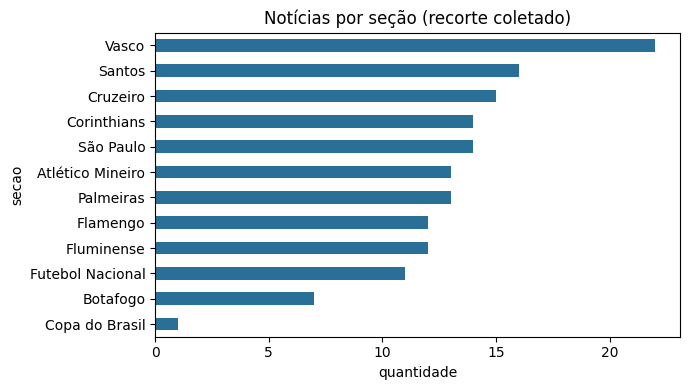

In [7]:
# Distribuição de notícias por seção
por_secao = df['secao'].fillna('Sem seção').value_counts()
ax = por_secao.plot(kind='barh', figsize=(7, 4), color='#2a6f97')
ax.set_title('Notícias por seção (recorte coletado)')
ax.set_xlabel('quantidade')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

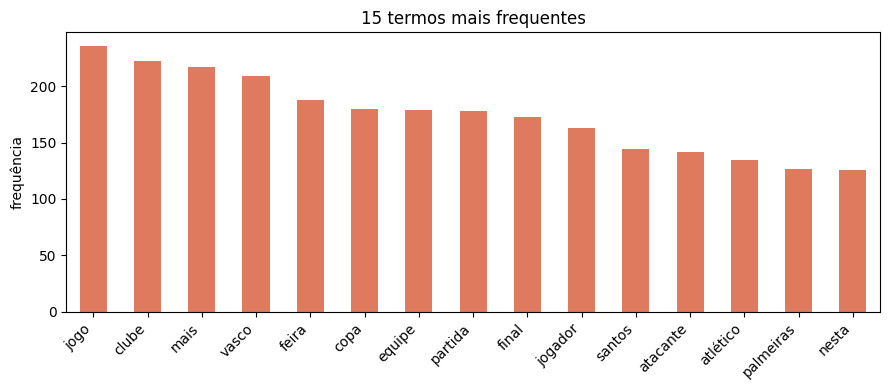

In [8]:
# Termos mais frequentes (após remoção de stopwords)
freq = Counter()
for linha in df['tokens_sem_stopwords'].dropna():
    freq.update(linha.split())
top = pd.Series(dict(freq.most_common(15)))
ax = top.plot(kind='bar', figsize=(9, 4), color='#e07a5f')
ax.set_title('15 termos mais frequentes')
ax.set_ylabel('frequência')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Rodada bônus — comparação entre recortes amostrais

### 5.1 Impacto de *stemming* vs. *lematização*

Comparamos quanto cada técnica reduz o vocabulário. O *stemming* corta sufixos
de forma agressiva (mais colisões, vocabulário menor); a lematização busca a
forma de dicionário (mais conservadora e legível).

In [9]:
tokens, stems, lemas = Counter(), Counter(), Counter()
for n in documento['noticias']:
    tokens.update(n['tokens_sem_stopwords'])
    stems.update(n['stems'])
    lemas.update(n['lemas'])

comparacao = pd.DataFrame({
    'representação': ['tokens (sem stopword)', 'stems', 'lemas'],
    'vocabulário único': [len(tokens), len(stems), len(lemas)],
})
comparacao['redução vs tokens (%)'] = (
    (1 - comparacao['vocabulário único'] / len(tokens)) * 100).round(1)
comparacao

,representação,vocabulário único,redução vs tokens (%)
0,tokens (sem stopword),5382,0.0
1,stems,3323,38.3
2,lemas,3683,31.6


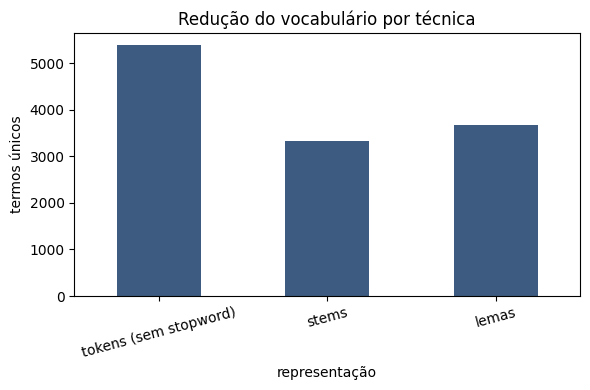

In [10]:
ax = comparacao.plot(x='representação', y='vocabulário único', kind='bar',
                     legend=False, figsize=(6, 4), color='#3d5a80')
ax.set_title('Redução do vocabulário por técnica')
ax.set_ylabel('termos únicos')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 5.2 Recorte por seção

Comparamos o vocabulário característico das duas seções com mais matérias no
recorte, evidenciando que fontes/seções diferentes produzem distribuições
lexicais distintas — útil para tarefas de classificação.

In [11]:
principais = df['secao'].fillna('Sem seção').value_counts().head(2).index.tolist()
print('Seções comparadas:', principais)

def termos_da_secao(secao, k=10):
    c = Counter()
    for _, linha in df[df['secao'].fillna('Sem seção') == secao].iterrows():
        if isinstance(linha['tokens_sem_stopwords'], str):
            c.update(linha['tokens_sem_stopwords'].split())
    return [t for t, _ in c.most_common(k)]

pd.DataFrame({s: termos_da_secao(s) for s in principais})

Seções comparadas: ['Vasco', 'Santos']


,Vasco,Santos
0,vasco,santos
1,clube,jogo
2,richarlison,gabriel
3,jogador,nesta
4,atacante,bontempo
5,cruz,neymar
6,mais,jogador
7,janela,clube
8,maltino,vila
9,tottenham,feira


### 5.3 Automatização da coleta

A coleta pode ser agendada de forma incremental (sem apagar o histórico) usando
o modo `--acumular`, que deduplica por identificador derivado da URL:

```bash
python pipeline.py --limite 30 --acumular
```

Basta agendar esse comando no **cron** (Linux/macOS) ou no **Agendador de
Tarefas** do Windows para construir uma série histórica diária.

## 6. Conclusões

- A base do Lance! é **adequada às tarefas de PLN**: volume crescente,
  variedade de clubes/seções e metadados interpretáveis.
- O pipeline entrega dados **tokenizados, normalizados e sem ruído/stopwords**,
  em JSON, JSONL e CSV, prontos para modelagem.
- Como bônus, oferecemos **stemming e lematização**, **comparação de recortes**
  amostrais e **automatização incremental** da coleta.
- Reprodutibilidade garantida por `requirements.txt` e por testes automatizados
  (`python -m unittest discover -s test`).